In [14]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


sns.set()

Here we will statistically prove that the LMSYS dataset has specific properties(redundancy and clustering) that makes semantic caching a vialbe stratergy,

In [9]:
CACHE_PATH = "../data/embeddings/train_data.npy"  # Shape: (437701, 384)
TEST_PATH = "../data/embeddings/test_data.npy"    # Shape: (136782, 384)
OUTPUT_DIR = "../results/characterization"

DIMENSION = 384
THRESHOLD_STRICT = 0.85
NUM_CLUSTERS = 100 # For K-Means Clustering

DIMENSION = 384
SIMILARITY_THRESHOLDS = [0.8, 0.85, 0.9]  # Multiple thresholds to analyze
NUM_CLUSTERS_LIST = [100, 500, 1000]  # Different k values for clustering
RANDOM_SEED = 42  # For reproducibility


os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load Data and Verification of Normalcy

In [7]:
def load_embeddings():
    """Load embeddings with memory mapping for efficiency"""
    print(f"Loading Cache embeddings from {CACHE_PATH}...")
    cache_emb = np.load(CACHE_PATH, mmap_mode='r')
    
    print(f"Loading Test embeddings from {TEST_PATH}...")
    test_emb = np.load(TEST_PATH, mmap_mode='r')
    
    print(f"\nCache embeddings shape: {cache_emb.shape}")
    print(f"Test embeddings shape: {test_emb.shape}")
    print(f"Dimension: {cache_emb.shape[1]}")
    
    return cache_emb, test_emb

def verify_embeddings(cache_emb, test_emb):
    """Verify embeddings are normalized (required for cosine similarity)"""
    print("\n=== VERIFYING EMBEDDINGS ===")
    
    # Sample 1000 random embeddings from each set
    cache_sample = cache_emb[np.random.choice(len(cache_emb), min(1000, len(cache_emb)), replace=False)]
    test_sample = test_emb[np.random.choice(len(test_emb), min(1000, len(test_emb)), replace=False)]
    
    # Compute L2 norms
    cache_norms = np.linalg.norm(cache_sample, axis=1)
    test_norms = np.linalg.norm(test_sample, axis=1)
    
    print(f"\nCache embeddings L2 norms:")
    print(f"  Mean: {cache_norms.mean():.4f}")
    print(f"  Std:  {cache_norms.std():.4f}")
    print(f"  Range: [{cache_norms.min():.4f}, {cache_norms.max():.4f}]")
    
    print(f"\nTest embeddings L2 norms:")
    print(f"  Mean: {test_norms.mean():.4f}")
    print(f"  Std:  {test_norms.std():.4f}")
    print(f"  Range: [{test_norms.min():.4f}, {test_norms.max():.4f}]")
    
    # Check if normalized
    cache_normalized = np.allclose(cache_norms, 1.0, atol=0.01)
    test_normalized = np.allclose(test_norms, 1.0, atol=0.01)
    
    print(f"\nCache embeddings normalized: {cache_normalized}")
    print(f"Test embeddings normalized: {test_normalized}")
    
    if not (cache_normalized and test_normalized):
        print("Embeddings are not normalized")
    else:
        print("\nEmbeddings are properly normalized.")
    
    return cache_normalized and test_normalized

# Load and verify
cache_emb, test_emb = load_embeddings()
is_normalized = verify_embeddings(cache_emb, test_emb)

Loading Cache embeddings from ../data/embeddings/train_data.npy...
Loading Test embeddings from ../data/embeddings/test_data.npy...

Cache embeddings shape: (437701, 384)
Test embeddings shape: (136782, 384)
Dimension: 384

=== VERIFYING EMBEDDINGS ===

Cache embeddings L2 norms:
  Mean: 1.0000
  Std:  0.0000
  Range: [1.0000, 1.0000]

Test embeddings L2 norms:
  Mean: 1.0000
  Std:  0.0000
  Range: [1.0000, 1.0000]

Cache embeddings normalized: True
Test embeddings normalized: True

Embeddings are properly normalized.


# Checking for Redundancy

In [31]:
def analyze_redundancy(cache_emb, test_emb):
    '''
    This function helps us proove REDUNDANCY: This means that the queries that are asked by the user do repeat
    themselves.
    '''
    print("Building FAISS Index (IndexFlatIP for Cosine Similarity)...")
    # IP = Inner Product. If vectors are normalized, IP == Cosine Similarity.
    index = faiss.IndexFlatIP(DIMENSION)
    
    # Load cache into RAM (approx 700MB)
    index.add(np.ascontiguousarray(cache_emb, dtype='float32'))
    
    print(f"Searching {test_emb.shape[0]} test queries...")
    test_data = np.ascontiguousarray(test_emb, dtype='float32')
    
    # Find the SINGLE best match (k=1) for every query
    # D will contain Similarity Scores (e.g., 0.92, 0.85)
    D, I = index.search(test_data, k=1)
    
    return D.flatten()

In [30]:
def load_data():
    print(f"Loading Cache (Train) from {CACHE_PATH}...")
    cache_emb = np.load(CACHE_PATH, mmap_mode='r')
    
    print(f"Loading Queries (Test) from {TEST_PATH}...")
    test_emb = np.load(TEST_PATH, mmap_mode='r')
    return cache_emb, test_emb

In [35]:
def plot_and_save(similarities):
    print("Plotting histogram...")
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of Similarity Scores
    plt.hist(similarities, bins=100, range=(0, 1), 
             color='blue', alpha=0.7, 
             label='Similarity Score')
    
    plt.axvline(THRESHOLD_STRICT, color='red', linestyle='--', linewidth=2, label='Cache Hit Threshold (0.85)')
    
    plt.title("Workload Characterization: Semantic Redundancy")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Number of Queries (Log Scale)")
    plt.yscale('log') # Log scale is crucial to see the small "hit" spikes
    plt.legend()
    plt.grid(True)
    
    outfile = os.path.join(OUTPUT_DIR, "redundancy_distribution.png")
    plt.savefig(outfile)
    print(f"Plot saved to: {outfile}")
    
    # Save Stats
    hit_rate = np.mean(similarities > THRESHOLD_STRICT)
    print(f"\n--- PAPER STATS ---")
    print(f"Avg Similarity: {np.mean(similarities):.4f}")
    print(f"Projected Cache Hit Rate (>0.85): {hit_rate*100:.2f}%")
    
    with open(os.path.join(OUTPUT_DIR, "redundancy_stats.json"), "w") as f:
        json.dump({"hit_rate_0.85": hit_rate, "mean_sim": float(np.mean(similarities))}, f)

Loading Cache (Train) from ../data/embeddings/train_data.npy...
Loading Queries (Test) from ../data/embeddings/test_data.npy...
Building FAISS Index (IndexFlatIP for Cosine Similarity)...
Searching 136782 test queries...
Plotting histogram...
Plot saved to: ../results/characterization/redundancy_distribution.png

--- PAPER STATS ---
Avg Similarity: 0.8786
Projected Cache Hit Rate (>0.85): 68.54%


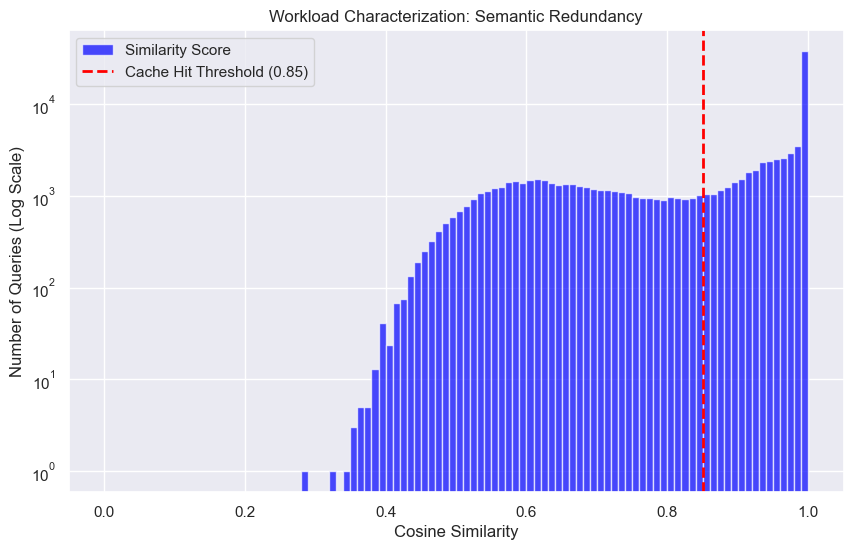

In [36]:
cache,test = load_data()
sims = analyze_redundancy(cache,test)
plot_and_save(sims)

# Checking Skewness

In [37]:
def compute_gini(array:np.ndarray) -> np.ndarray:
    '''This function helps in calculating the gini-index'''
    mad = np.abs(np.subtract.outer(array,array)).mean()
    rmad = mad / np.mean(array)
    gini = 0.5 * rmad
    return gini

In [12]:
def run_clustering_analysis(embeddings, k_values=NUM_CLUSTERS_LIST):
    """
    Run K-Means clustering with multiple k values to analyze semantic clustering
    """
    print(f"\n=== CLUSTERING ANALYSIS ===")
    
    results = {}
    
    for k in k_values:
        print(f"\nRunning K-Means with k={k}...")
        
        # Run K-Means
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10, max_iter=300)
        labels = kmeans.fit_predict(embeddings)
        
        # Compute cluster sizes
        cluster_sizes = np.bincount(labels)
        sorted_sizes = np.sort(cluster_sizes)[::-1]  # Descending order
        
        # Compute Gini coefficient
        gini = compute_gini(cluster_sizes)
        
        # Compute statistics
        stats = {
            "k": k,
            "gini_coefficient": float(gini),
            "mean_size": float(np.mean(cluster_sizes)),
            "std_size": float(np.std(cluster_sizes)),
            "min_size": int(np.min(cluster_sizes)),
            "max_size": int(np.max(cluster_sizes)),
            "median_size": float(np.median(cluster_sizes)),
            "top10_pct": float(sorted_sizes[:10].sum() / len(embeddings) * 100),
            "top50_pct": float(sorted_sizes[:50].sum() / len(embeddings) * 100) if k >= 50 else None
        }
        
        print(f"  Gini coefficient: {gini:.4f}")
        print(f"  Mean cluster size: {stats['mean_size']:.1f}")
        print(f"  Cluster size range: [{stats['min_size']}, {stats['max_size']}]")
        print(f"  Top 10 clusters contain: {stats['top10_pct']:.2f}% of data")
        if stats['top50_pct'] is not None:
            print(f"  Top 50 clusters contain: {stats['top50_pct']:.2f}% of data")
        
        results[k] = {
            "stats": stats,
            "cluster_sizes": cluster_sizes.tolist(),
            "labels": labels
        }
    
    return results


In [39]:
def plot_lorenz_curve(cluster_sizes):
    """
    Plots the Lorenz curve to visualize inequality (clustering).
    """
    print("Plotting Lorenz Curve...")
    n = len(cluster_sizes)
    # Sort small to large for Lorenz
    sorted_asc = np.sort(cluster_sizes)
    
    # Cumulative sums
    cum_clusters = np.arange(1, n + 1) / n
    cum_queries = np.cumsum(sorted_asc) / np.sum(sorted_asc)
    
    plt.figure(figsize=(8, 8))
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality (Gini=0)')
    plt.plot(cum_clusters, cum_queries, color='blue', linewidth=2, label='Actual Distribution')
    
    plt.title("Lorenz Curve: Query Distribution Across Topics")
    plt.xlabel("Cumulative % of Clusters (Topics)")
    plt.ylabel("Cumulative % of Queries")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    outfile = os.path.join(OUTPUT_DIR, "clustering_lorenz_curve.png")
    plt.savefig(outfile)
    print(f"Saved plot: {outfile}")

In [ ]:
def plot_clustering_results(clustering_results):
    """Create publication-quality clustering visualizations"""
    n_configs = len(clustering_results)
    fig, axes = plt.subplots(2, n_configs, figsize=(6*n_configs, 10))
    
    if n_configs == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (k, result) in enumerate(clustering_results.items()):
        cluster_sizes = np.array(result['cluster_sizes'])
        sorted_sizes = np.sort(cluster_sizes)[::-1]
        gini = result['stats']['gini_coefficient']
        
        # Lorenz curve
        cumulative_sizes = np.cumsum(sorted_sizes) / np.sum(sorted_sizes)
        cumulative_clusters = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes)
        
        axes[0, i].plot([0, 1], [0, 1], 'k--', label='Perfect Equality', linewidth=2)
        axes[0, i].plot(cumulative_clusters, cumulative_sizes, 'b-', 
                       label=f'Actual (Gini={gini:.3f})', linewidth=2)
        axes[0, i].fill_between(cumulative_clusters, cumulative_sizes, cumulative_clusters, 
                               alpha=0.3, color='blue')
        axes[0, i].set_xlabel('Cumulative % of Clusters', fontsize=12)
        axes[0, i].set_ylabel('Cumulative % of Data', fontsize=12)
        axes[0, i].set_title(f'Lorenz Curve (k={k})', fontsize=14)
        axes[0, i].legend(fontsize=10)
        axes[0, i].grid(True, alpha=0.3)
        
        # Cluster size distribution
        axes[1, i].bar(range(len(sorted_sizes)), sorted_sizes, color='purple', alpha=0.7)
        axes[1, i].set_xlabel('Cluster Rank', fontsize=12)
        axes[1, i].set_ylabel('Cluster Size', fontsize=12)
        axes[1, i].set_title(f'Cluster Size Distribution (k={k})', fontsize=14)
        axes[1, i].set_yscale('log')
        axes[1, i].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    filename = f"{OUTPUT_DIR}/clustering_analysis.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✅ Plot saved to: {filename}")
    plt.show()

# Run clustering analysis
clustering_results = run_clustering_analysis(cache_emb)
plot_clustering_results(clustering_results)


=== CLUSTERING ANALYSIS ===

Running K-Means with k=100...


In [41]:
def main():
    cluster_sizes = run_clustering_analysis(train_data)
    
    # Compute Stats
    gini = compute_gini(cluster_sizes)
    top_10_percent_share = np.sum(cluster_sizes[:10]) / np.sum(cluster_sizes)
    
    print("\n--- RESULTS FOR PAPER ---")
    print(f"Gini Coefficient: {gini:.4f}")
    print(f"Top 10 Clusters hold {top_10_percent_share*100:.1f}% of all queries")
    
    # Save Stats
    stats = {
        "gini_coefficient": float(gini),
        "top_10_clusters_share": float(top_10_percent_share),
        "num_clusters": NUM_CLUSTERS
    }
    with open(os.path.join(OUTPUT_DIR, "clustering_stats.json"), "w") as f:
        json.dump(stats, f, indent=4)
        
    # Plot
    plot_lorenz_curve(cluster_sizes)
    plot_cluster_sizes(cluster_sizes)

Running K-Means (k=100) on 437701 vectors...
Sampling a subset of 25600 / 437701 for training
Clustering 25600 points in 384D to 100 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.09 s
Assigning queries to clusters....09 s): objective=16937.3 imbalance=1.290 nsplit=0       

--- RESULTS FOR PAPER ---
Gini Coefficient: 0.2622
Top 10 Clusters hold 21.6% of all queries
Plotting Lorenz Curve...
Saved plot: ../results/characterization/clustering_lorenz_curve.png
Plotting Cluster Size Distribution...
Saved plot: ../results/characterization/clustering_histogram.png


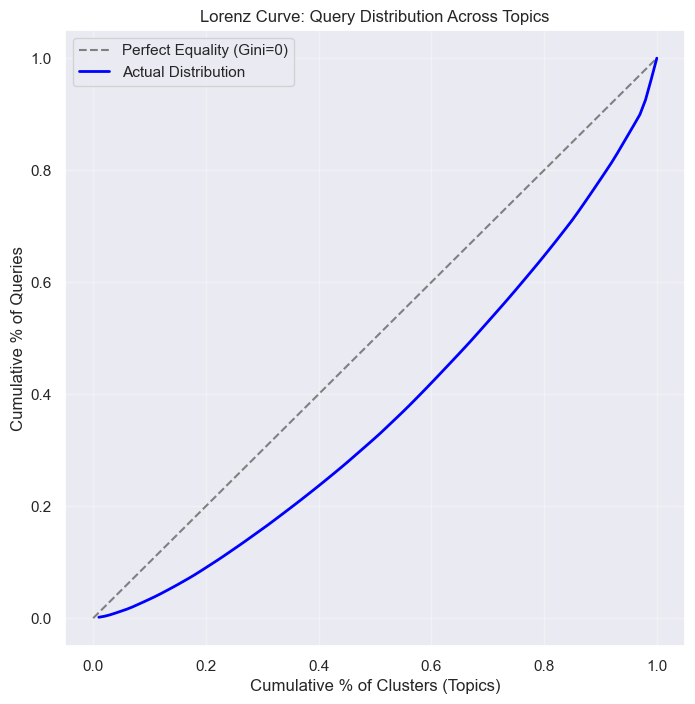

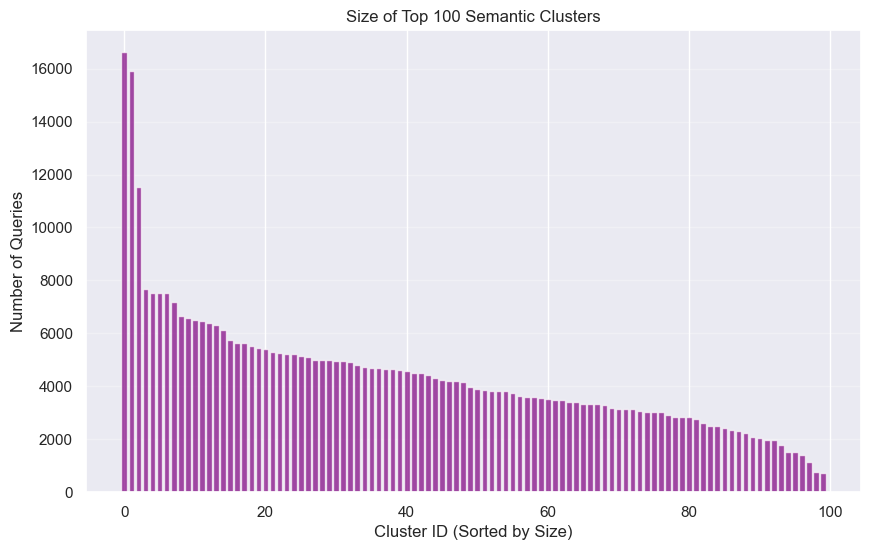

In [44]:
main()

# Nearest Neighbor Distance Distribution


=== ANALYZING NEAREST NEIGHBOR DISTANCES (k=10) ===
Building FAISS Index...
Finding 10 nearest neighbors for 136782 test queries...

Predicted cache hit rates:
  Threshold 0.8: 72.10%
  Threshold 0.85: 68.54%
  Threshold 0.9: 64.19%

1-NN Statistics:
  Mean:   0.8786
  Median: 0.9840
  Std:    0.1642
  Range:  [0.2869, 1.0000]


/var/folders/4j/h4tbr0nx3x7883_kb4sxg03m0000gn/T/ipykernel_5409/877886236.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(threshold_groups, labels=labels, patch_artist=True)



✅ Plot saved to: ../results/characterization/nn_distance_distribution.png


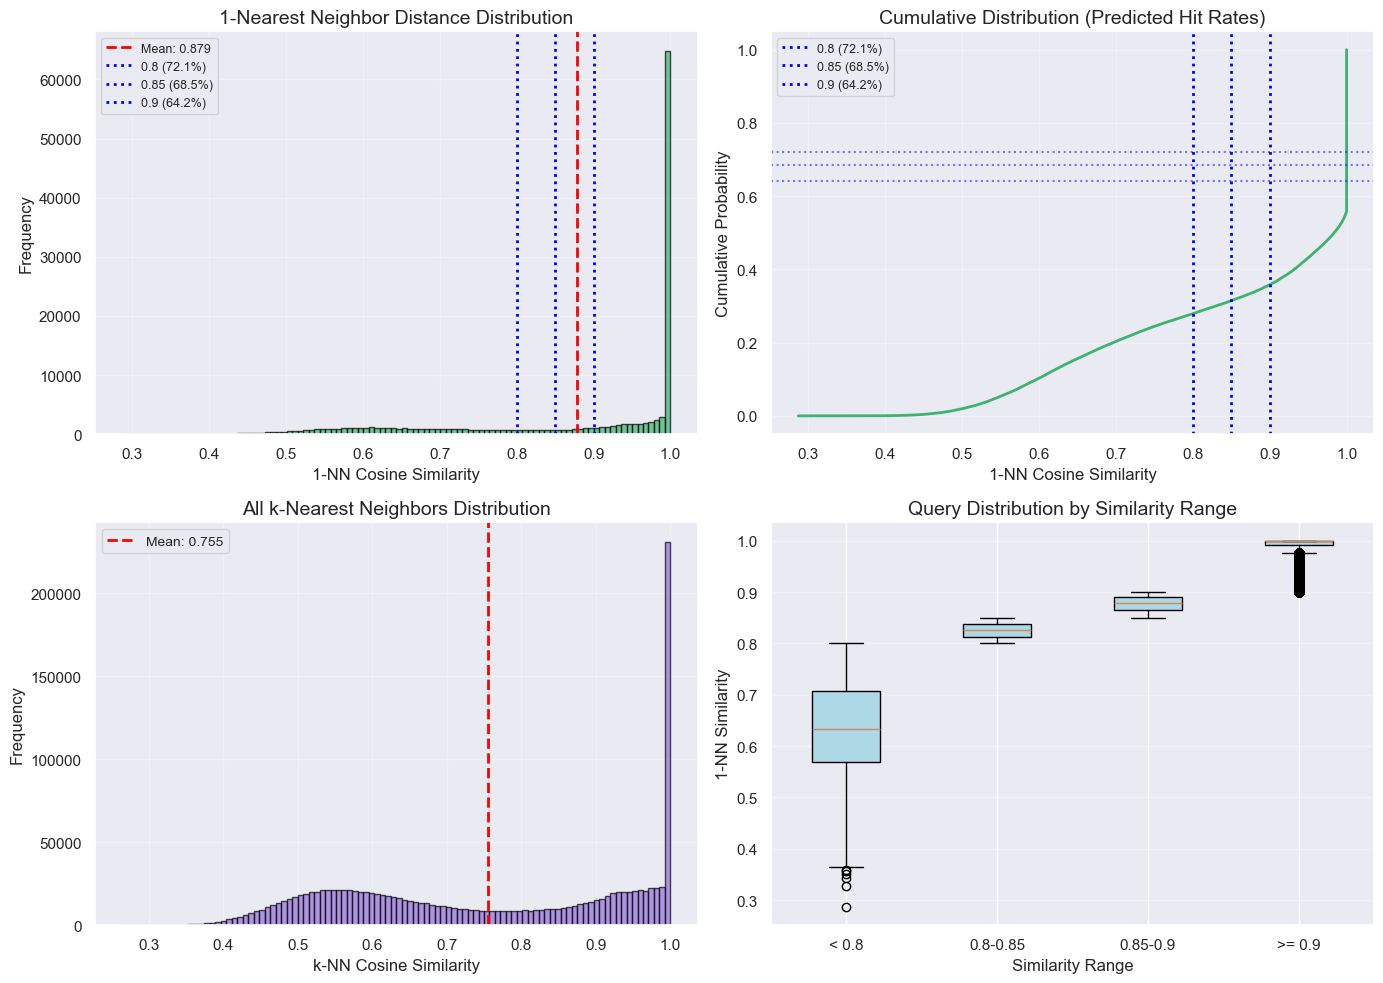

In [10]:
def analyze_nn_distances(cache_emb, test_emb, k=10):
    """
    For each test query, find distance to k nearest neighbors in cache.
    This predicts cache hit rates at different similarity thresholds.
    """
    print(f"\n=== ANALYZING NEAREST NEIGHBOR DISTANCES (k={k}) ===")
    
    # Build FAISS index
    print("Building FAISS Index...")
    index = faiss.IndexFlatIP(DIMENSION)  # Inner product = cosine similarity for normalized vectors
    index.add(cache_emb.astype('float32'))
    
    # Find k nearest neighbors for each test query
    print(f"Finding {k} nearest neighbors for {len(test_emb)} test queries...")
    distances, indices = index.search(test_emb.astype('float32'), k=k)
    
    # Extract 1-NN (closest neighbor) similarities
    nn1_similarities = distances[:, 0]
    
    # Compute statistics
    stats = {
        "k": k,
        "mean_1nn_similarity": float(np.mean(nn1_similarities)),
        "std_1nn_similarity": float(np.std(nn1_similarities)),
        "median_1nn_similarity": float(np.median(nn1_similarities)),
        "min_1nn_similarity": float(np.min(nn1_similarities)),
        "max_1nn_similarity": float(np.max(nn1_similarities))
    }
    
    # Compute predicted hit rates at different thresholds
    print(f"\nPredicted cache hit rates:")
    for threshold in SIMILARITY_THRESHOLDS:
        hit_rate = (nn1_similarities >= threshold).mean() * 100
        stats[f"predicted_hit_rate_{threshold}"] = float(hit_rate)
        print(f"  Threshold {threshold}: {hit_rate:.2f}%")
    
    # Analyze distribution across all k neighbors
    all_distances = distances.flatten()
    stats["mean_knn_similarity"] = float(np.mean(all_distances))
    stats["median_knn_similarity"] = float(np.median(all_distances))
    
    print(f"\n1-NN Statistics:")
    print(f"  Mean:   {stats['mean_1nn_similarity']:.4f}")
    print(f"  Median: {stats['median_1nn_similarity']:.4f}")
    print(f"  Std:    {stats['std_1nn_similarity']:.4f}")
    print(f"  Range:  [{stats['min_1nn_similarity']:.4f}, {stats['max_1nn_similarity']:.4f}]")
    
    return nn1_similarities, all_distances, stats

def plot_nn_distance_distribution(nn1_similarities, all_distances):
    """Create publication-quality NN distance plots"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1-NN histogram
    axes[0, 0].hist(nn1_similarities, bins=100, alpha=0.7, color='mediumseagreen', edgecolor='black')
    axes[0, 0].axvline(np.mean(nn1_similarities), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(nn1_similarities):.3f}', linewidth=2)
    
    for threshold in SIMILARITY_THRESHOLDS:
        pct = (nn1_similarities >= threshold).mean() * 100
        axes[0, 0].axvline(threshold, color='blue', linestyle=':', 
                          label=f'{threshold} ({pct:.1f}%)', linewidth=2)
    
    axes[0, 0].set_xlabel('1-NN Cosine Similarity', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('1-Nearest Neighbor Distance Distribution', fontsize=14)
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 1-NN CDF
    sorted_sims = np.sort(nn1_similarities)
    cumulative = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
    axes[0, 1].plot(sorted_sims, cumulative, linewidth=2, color='mediumseagreen')
    
    for threshold in SIMILARITY_THRESHOLDS:
        pct = (nn1_similarities >= threshold).mean() * 100
        axes[0, 1].axvline(threshold, color='blue', linestyle=':', 
                          label=f'{threshold} ({pct:.1f}%)', linewidth=2)
        axes[0, 1].axhline(pct/100, color='blue', linestyle=':', alpha=0.5)
    
    axes[0, 1].set_xlabel('1-NN Cosine Similarity', fontsize=12)
    axes[0, 1].set_ylabel('Cumulative Probability', fontsize=12)
    axes[0, 1].set_title('Cumulative Distribution (Predicted Hit Rates)', fontsize=14)
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # All k-NN histogram
    axes[1, 0].hist(all_distances, bins=100, alpha=0.7, color='mediumpurple', edgecolor='black')
    axes[1, 0].axvline(np.mean(all_distances), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(all_distances):.3f}', linewidth=2)
    axes[1, 0].set_xlabel('k-NN Cosine Similarity', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('All k-Nearest Neighbors Distribution', fontsize=14)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Box plot by threshold
    threshold_groups = []
    labels = []
    for i, threshold in enumerate(SIMILARITY_THRESHOLDS):
        if i == 0:
            # Below first threshold
            group = nn1_similarities[nn1_similarities < threshold]
            threshold_groups.append(group)
            labels.append(f'< {threshold}')
        else:
            # Between thresholds
            prev_threshold = SIMILARITY_THRESHOLDS[i-1]
            group = nn1_similarities[(nn1_similarities >= prev_threshold) & (nn1_similarities < threshold)]
            threshold_groups.append(group)
            labels.append(f'{prev_threshold}-{threshold}')
    
    # Above last threshold
    group = nn1_similarities[nn1_similarities >= SIMILARITY_THRESHOLDS[-1]]
    threshold_groups.append(group)
    labels.append(f'>= {SIMILARITY_THRESHOLDS[-1]}')
    
    bp = axes[1, 1].boxplot(threshold_groups, labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    axes[1, 1].set_xlabel('Similarity Range', fontsize=12)
    axes[1, 1].set_ylabel('1-NN Similarity', fontsize=12)
    axes[1, 1].set_title('Query Distribution by Similarity Range', fontsize=14)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    filename = f"{OUTPUT_DIR}/nn_distance_distribution.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✅ Plot saved to: {filename}")
    plt.show()

# Run NN distance analysis
nn1_similarities, all_distances, nn_stats = analyze_nn_distances(cache_emb, test_emb, k=10)
plot_nn_distance_distribution(nn1_similarities, all_distances)

In [11]:
# Install UMAP if not already installed
try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    !pip install umap-learn
    import umap

def create_dimensionality_reduction_visualization(embeddings, labels, method='umap', sample_size=10000):
    """
    Create 2D visualization of embeddings using UMAP or t-SNE
    """
    print(f"\n=== CREATING {method.upper()} VISUALIZATION ===")
    
    # Sample embeddings if too large
    if len(embeddings) > sample_size:
        print(f"Sampling {sample_size} points for visualization...")
        sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
        sample_emb = embeddings[sample_indices]
        sample_labels = labels[sample_indices]
    else:
        sample_emb = embeddings
        sample_labels = labels
    
    # Run dimensionality reduction
    if method == 'umap':
        print("Running UMAP (this may take a few minutes)...")
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            metric='cosine',
            random_state=RANDOM_SEED,
            verbose=True
        )
        embedding_2d = reducer.fit_transform(sample_emb)
    else:  # t-SNE
        from sklearn.manifold import TSNE
        print("Running t-SNE (this may take a few minutes)...")
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            random_state=RANDOM_SEED,
            verbose=1
        )
        embedding_2d = reducer.fit_transform(sample_emb)
    
    print("Creating visualization...")
    
    # Create figure with multiple views
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Plot 1: Colored by cluster
    scatter1 = axes[0].scatter(
        embedding_2d[:, 0], 
        embedding_2d[:, 1],
        c=sample_labels,
        cmap='tab20',
        s=2,
        alpha=0.6
    )
    axes[0].set_title(f'{method.upper()} Projection (Colored by Cluster)', fontsize=16)
    axes[0].set_xlabel(f'{method.upper()} Dimension 1', fontsize=12)
    axes[0].set_ylabel(f'{method.upper()} Dimension 2', fontsize=12)
    plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')
    
    # Plot 2: Density visualization
    from scipy.stats import gaussian_kde
    
    # Calculate point density
    xy = embedding_2d.T
    z = gaussian_kde(xy)(xy)
    
    scatter2 = axes[1].scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        c=z,
        cmap='viridis',
        s=2,
        alpha=0.6
    )
    axes[1].set_title(f'{method.upper()} Projection (Density)', fontsize=16)
    axes[1].set_xlabel(f'{method.upper()} Dimension 1', fontsize=12)
    axes[1].set_ylabel(f'{method.upper()} Dimension 2', fontsize=12)
    plt.colorbar(scatter2, ax=axes[1], label='Point Density')
    
    plt.tight_layout()
    
    filename = f"{OUTPUT_DIR}/{method}_visualization.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✅ Plot saved to: {filename}")
    plt.show()
    
    return embedding_2d

# Create UMAP visualization with k=100 clustering
k_for_viz = 100
labels_for_viz = clustering_results[k_for_viz]['labels']

umap_embedding = create_dimensionality_reduction_visualization(
    cache_emb, 
    labels_for_viz, 
    method='umap',
    sample_size=10000
)

# Optionally create t-SNE visualization as well
# tsne_embedding = create_dimensionality_reduction_visualization(
#     cache_emb, 
#     labels_for_viz, 
#     method='tsne',
#     sample_size=10000
# )

NameError: name 'clustering_results' is not defined